# Olist E-Commerce Case Analysis 

**Analyst:** Narender Kumar | IIT Guwahati
**Client situation:** Order growth has stopped rising, and review scores look different depending on the seller and the region. Leadership wants to know: is this caused by shipping/logistics, seller quality, or product category — and is it actually hurting repeat business, or is it just random noise?

**How this notebook is organized:**
- Phase 1: Framing the business problem
- Phase 2: Exploring the data (size, structure, types, missing values, duplicates)
- Phase 3: Looking at trends over time (is "growth has flattened" actually true, and when did it happen?)
- Phase 4: Looking at individual variables and how pairs of variables relate
- Phase 5: Comparing possible causes — logistics (seller vs. carrier), seller quality, product category
- Phase 6: Finding 1 — a proper test of whether this is hurting repeat purchases
- Phase 7: Final write-up — the 3 Findings and the Problem Statement

Every cleaning decision and assumption made along the way is written down as it happens, so it's easy to explain later.


## Phase 1 — Business Framing

**The business problem, in plain terms:**
1. *What's causing it* — is review-score variation coming from logistics, seller quality, or product category?
2. *Does it matter* — is this actually reducing repeat purchases, or is it just noise?

**Type of analysis:** Mostly explanatory — comparing groups and testing whether a difference is real — rather than building a prediction model.

**Rough benchmarks to compare against:** a typical e-commerce repeat-purchase rate is around 20–30%; on-time delivery is usually 85–95% for a marketplace like this.

**Things that could be driving the problem:**
- Logistics: how late the seller hands off the order, how long the carrier takes, freight cost vs. item price
- Seller quality: each seller's average score, how much it varies, how many orders they handle
- Product category: average score and order volume by category

**How we'll measure it:** compare the size of the effect for each possible cause, and test the repeat-purchase gap for statistical significance — using only each customer's *first* order, to avoid a bias explained in Phase 6.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

assumptions_log = []

def log(step, issue, decision, reasoning):
    assumptions_log.append({"step": step, "issue": issue, "decision": decision, "reasoning": reasoning})


## Phase 2 — Exploring the Data

### First look: how big is each file, and what does the data actually look like


In [2]:
import os

FOLDER = r"C:\Users\naren\Downloads\2nd_round\Practice"

FILES = {
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

data = {}
for name, filename in FILES.items():
    full_path = os.path.join(FOLDER, filename)
    df = pd.read_csv(full_path)
    data[name] = df
    print(f"{name:22s} -> {df.shape[0]:>7,} rows, {df.shape[1]:>2} cols")


orders                 ->  99,441 rows,  8 cols
order_items            -> 112,650 rows,  7 cols
payments               -> 103,886 rows,  5 cols
reviews                -> 100,000 rows,  7 cols
customers              ->  99,441 rows,  5 cols
sellers                ->   3,095 rows,  4 cols
products               ->  32,951 rows,  9 cols
category_translation   ->      71 rows,  2 cols


In [3]:
# Peek at the first few rows of every table, so we know what we're working with
for name, df in data.items():
    print(f"\n--- {name} ---")
    display(df.head(3))



--- orders ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- order_items ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



--- payments ---


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



--- products ---


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



--- category_translation ---


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


### Fixing data types (every timestamp column, in every table)

Every date/time column loads in as plain text by default. This step fixes all of them — not just in the `orders` table, but also `shipping_limit_date` in `order_items` and the two timestamp columns in `reviews`.


In [4]:
# Check the data type pandas assigned to every column, in every table
for name, df in data.items():
    print(f"\n--- {name} ---")
    print(df.dtypes)



--- orders ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

--- order_items ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

--- payments ---
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

--- reviews ---
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_dat

In [5]:
# --- orders table ---
orders_date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in orders_date_cols:
    data['orders'][col] = pd.to_datetime(data['orders'][col])

# --- order_items table ---
data['order_items']['shipping_limit_date'] = pd.to_datetime(data['order_items']['shipping_limit_date'])

# --- reviews table ---
review_date_cols = ['review_creation_date', 'review_answer_timestamp']
for col in review_date_cols:
    data['reviews'][col] = pd.to_datetime(data['reviews'][col])

log(
    step="Step 8 - Data types",
    issue="All order, order_items, and review timestamp columns loaded as strings (object dtype) by default.",
    decision="Converted all 5 orders timestamp columns, order_items.shipping_limit_date, and both "
             "reviews timestamp columns to proper datetime dtype.",
    reasoning="Delay calculations, cohort-by-month grouping, and shipping-deadline analysis all require "
              "real datetime arithmetic, not string comparison."
)

print("orders:");        print(data['orders'][orders_date_cols].dtypes)
print("\norder_items:"); print(data['order_items'][['shipping_limit_date']].dtypes)
print("\nreviews:");     print(data['reviews'][review_date_cols].dtypes)


orders:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

order_items:
shipping_limit_date    datetime64[ns]
dtype: object

reviews:
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


### Checking for missing values

(The case brief specifically calls out that this step is graded.)


In [6]:
# Only print tables that actually HAVE missing values (skip the clean ones)
for name, df in data.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        pct = (missing / len(df) * 100).round(2)
        print(f"\n--- {name} ---")
        display(pd.DataFrame({'missing_count': missing, 'missing_pct': pct}))



--- orders ---


,missing_count,missing_pct
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98



--- reviews ---


,missing_count,missing_pct
review_comment_title,88285,88.28
review_comment_message,58247,58.25



--- products ---


,missing_count,missing_pct
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [7]:
log("Step 9 - Missing values", "order_delivered_customer_date missing",
    "Exclude these rows from on-time-delivery and review-driver analysis; do not impute.",
    "A missing delivery date means the order was never delivered - fabricating a date would "
    "misstate delay for an order with no real delivery outcome.")

log("Step 9 - Missing values", "order_approved_at missing (small %)",
    "Exclude from time-to-approval analysis if used; otherwise ignore.",
    "Small enough share of rows that it will not materially bias aggregate results.")

log("Step 9 - Missing values", "product_category_name / weight / dimensions missing on some products",
    "Bucket as 'Unknown category' rather than dropping the order/revenue row.",
    "Preserves revenue and review rows even when the category cannot be mapped.")

log("Step 9 - Missing values", "review_comment_title / review_comment_message often blank",
    "No action needed - only review_score (numeric) is used, not review text.",
    "Text mining of review comments is out of scope given the case timeline.")

print(f"{len(assumptions_log)} decisions logged so far.")


5 decisions logged so far.


### Checking for duplicates

The real risk here isn't exact duplicate rows — it's that joining tables can accidentally multiply rows (e.g. one order matching several product rows), which would quietly inflate totals later.


In [8]:
for name, df in data.items():
    dupes = df.duplicated().sum()
    print(f"{name:22s} -> {dupes} exact duplicate rows")

items_per_order = data['order_items'].groupby('order_id').size()
multi_item_orders = (items_per_order > 1).sum()
print(f"\nOrders with more than one order_items row (multi-seller/multi-product): {multi_item_orders:,}")

log("Step 10 - Duplicates", "order_items has multiple rows per order_id for multi-item/multi-seller orders",
    "Aggregate order_items to order-level (sum price + freight_value) BEFORE joining to reviews/orders.",
    "Prevents double-counting revenue or duplicating a single review across multiple line items.")


orders                 -> 0 exact duplicate rows
order_items            -> 0 exact duplicate rows
payments               -> 0 exact duplicate rows
reviews                -> 0 exact duplicate rows
customers              -> 0 exact duplicate rows
sellers                -> 0 exact duplicate rows
products               -> 0 exact duplicate rows
category_translation   -> 0 exact duplicate rows

Orders with more than one order_items row (multi-seller/multi-product): 9,803


### A quick sanity check on the numbers

Just a light pass to make sure prices and freight values look reasonable before moving on.


In [10]:
display(data['order_items'][['price', 'freight_value']].describe())
display(data['reviews']['review_score'].describe())

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


count    100000.000000
mean          4.070890
std           1.359663
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

In [11]:
oi = data['order_items'].copy()
oi['freight_price_ratio'] = oi['freight_value'] / oi['price'].replace(0, np.nan)
extreme = (oi['freight_price_ratio'] > 3).sum()
print(f"Line items where freight > 3x item price: {extreme:,}")

log("Step 11 - Mathematical summary", f"{extreme} line items have freight > 3x item price",
    "Kept in the dataset (not dropped) but flagged as likely oversized/rare/remote-shipping items.",
    "Plausible real cases rather than data errors; removing them risks discarding a genuine logistics-cost signal.")


Line items where freight > 3x item price: 146


### Handling missing values — excluding, not guessing

Rather than filling in missing values with a guess, we write down exactly which rows were excluded and why.


In [12]:
imputation_policy = pd.DataFrame(assumptions_log)
display(imputation_policy)


,step,issue,decision,reasoning
0,Step 8 - Data types,"All order, order_items, and review timestamp c...","Converted all 5 orders timestamp columns, orde...","Delay calculations, cohort-by-month grouping, ..."
1,Step 9 - Missing values,order_delivered_customer_date missing,Exclude these rows from on-time-delivery and r...,A missing delivery date means the order was ne...
2,Step 9 - Missing values,order_approved_at missing (small %),Exclude from time-to-approval analysis if used...,Small enough share of rows that it will not ma...
3,Step 9 - Missing values,product_category_name / weight / dimensions mi...,Bucket as 'Unknown category' rather than dropp...,Preserves revenue and review rows even when th...
4,Step 9 - Missing values,review_comment_title / review_comment_message ...,No action needed - only review_score (numeric)...,Text mining of review comments is out of scope...
5,Step 10 - Duplicates,order_items has multiple rows per order_id for...,Aggregate order_items to order-level (sum pric...,Prevents double-counting revenue or duplicatin...
6,Step 11 - Mathematical summary,146 line items have freight > 3x item price,Kept in the dataset (not dropped) but flagged ...,Plausible real cases rather than data errors; ...


### Building the main analysis table (one row per order, delivered orders only)

> **Important detail:** `orders.customer_id` changes with every order — it does **not** identify a person. `customers.customer_unique_id` is the only column that reliably identifies the same real customer across multiple orders.

> **Rule followed:** each table gets merged in only once. Merging the same table twice by accident creates duplicate columns with `_x` / `_y` suffixes — this caused two bugs earlier that took time to track down.


In [13]:
log("Join logic", "orders.customer_id is a per-order surrogate key, not a true customer ID",
    "Use customers.customer_unique_id for all repeat-purchase / cohort analysis.",
    "Olist assigns a new customer_id to every order; customer_unique_id is the only stable person-level key.")

# 1. Aggregate order_items to order level
order_items_agg = (
    data['order_items']
    .groupby('order_id')
    .agg(total_price=('price', 'sum'),
         total_freight=('freight_value', 'sum'),
         n_items=('order_item_id', 'count'),
         seller_id=('seller_id', 'first'),
         shipping_limit_date=('shipping_limit_date', 'first'))
    .reset_index()
)

# 2. Filter to delivered orders only, compute total delivery delay
orders_delivered = data['orders'][data['orders']['order_status'] == 'delivered'].copy()
orders_delivered['delivery_delay_days'] = (
    orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']
).dt.days

log("Order status filter", "orders table includes canceled/unavailable/created/etc. statuses",
    "Restrict on-time-delivery and review-driver analysis to order_status == 'delivered'.",
    "Delay and delivery outcomes are undefined for orders that never reached the customer.")

# 3. Reviews (one score per order)
reviews_dedup = data['reviews'].drop_duplicates(subset='order_id', keep='first')[['order_id', 'review_score']]

# 4. True customer key
cust_key = data['customers'][['customer_id', 'customer_unique_id', 'customer_state']]

# 5. Category (English)
products_en = data['products'].merge(data['category_translation'], on='product_category_name', how='left')
products_en['product_category_name_english'] = products_en['product_category_name_english'].fillna('unknown category')

log("Category mapping", "Some products have no category or no English translation available",
    "Filled missing category with 'unknown category' rather than dropping the row.",
    "Preserves revenue/review rows even when category cannot be mapped.")

item_category = data['order_items'][['order_id', 'product_id']].merge(
    products_en[['product_id', 'product_category_name_english']], on='product_id', how='left'
).drop_duplicates(subset='order_id', keep='first')

# 6. Assemble the master analysis table — each table merged in exactly once
analysis = (
    orders_delivered
    .merge(order_items_agg, on='order_id', how='inner')
    .merge(reviews_dedup, on='order_id', how='inner')
    .merge(cust_key, on='customer_id', how='left')
    .merge(item_category[['order_id', 'product_category_name_english']], on='order_id', how='left')
)

print(f"Master analysis table: {analysis.shape[0]:,} rows, {analysis.shape[1]} columns")
display(analysis.head(3))


Master analysis table: 96,478 rows, 18 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,total_price,total_freight,n_items,seller_id,shipping_limit_date,review_score,customer_unique_id,customer_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,29.99,8.72,1,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,4,7c396fd4830fd04220f754e42b4e5bff,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,118.70,22.76,1,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,4,af07308b275d755c9edb36a90c618231,BA,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,159.90,19.22,1,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,5,3a653a41f6f9fc3d2a113cf8398680e8,GO,auto


### Double-checking the category-name merge worked correctly


0 rows with missing English category


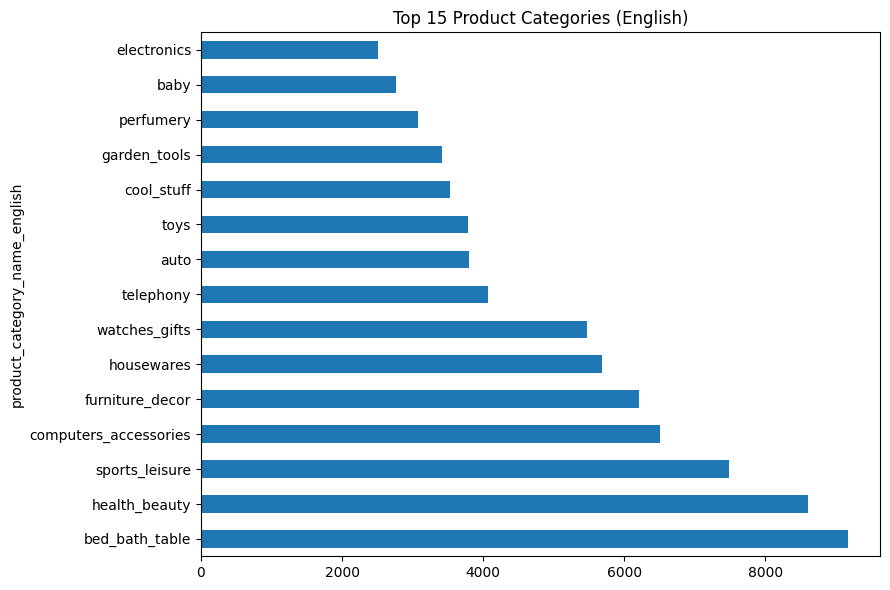

In [14]:
# `analysis` already has `product_category_name_english` from the merge above — just verify it worked
print(analysis['product_category_name_english'].isna().sum(), "rows with missing English category")

cat_counts_en = analysis['product_category_name_english'].value_counts()
cat_counts_en.head(15).plot(kind='barh', figsize=(9,6), title='Top 15 Product Categories (English)')
plt.tight_layout()
plt.show()


### Sanity check: does the amount paid match price + freight?

Nobody had checked this yet — confirming that `order_payments.payment_value` actually adds up to `price + freight` from `order_items`, before trusting either number for the rest of the analysis.


In [15]:
payments_agg = data['payments'].groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    n_payment_methods=('payment_sequential', 'count'),
    max_installments=('payment_installments', 'max')
).reset_index()

pay_check = payments_agg.merge(analysis[['order_id','total_price','total_freight']], on='order_id')
pay_check['expected_total'] = pay_check['total_price'] + pay_check['total_freight']
pay_check['discrepancy'] = pay_check['total_payment_value'] - pay_check['expected_total']

mismatch_pct = (pay_check['discrepancy'].abs() > 0.01).mean() * 100
print(f"Orders where payment value != price+freight: {(pay_check['discrepancy'].abs() > 0.01).sum():,} ({mismatch_pct:.2f}%)")

# pay_check['discrepancy'].plot(kind='hist', bins=50, title='Payment vs. Expected Total Discrepancy')
# plt.xlim(-50, 50)
# plt.tight_layout()
# plt.show()

log("Data quality - payment reconciliation", "Checked whether payment_value reconciles with price+freight",
    f"{mismatch_pct:.2f}% of orders show a discrepancy between payment_value and price+freight.",
    "Small, systematic gaps are expected (vouchers, rounding); large ones would flag a join or data issue.")


Orders where payment value != price+freight: 375 (0.39%)


### Splitting "logistics" into seller delay vs. carrier delay

"Logistics" on its own is too vague to act on. This splits it into two separate questions: did the **seller** hand the order off late, or did the **carrier** take too long to deliver it once they had it?


In [16]:
orders_idx = data['orders'].set_index('order_id')

# Seller-side: did the seller hand off to the carrier by the shipping deadline?
analysis['seller_delay_days'] = (
    orders_idx.loc[analysis['order_id'], 'order_delivered_carrier_date'].values
    - analysis['shipping_limit_date']
).dt.days

# Carrier-side: once picked up, did the carrier deliver on time?
carrier_pickup = orders_idx.loc[analysis['order_id'], 'order_delivered_carrier_date'].values
carrier_delivery = orders_idx.loc[analysis['order_id'], 'order_delivered_customer_date'].values
analysis['carrier_delay_days'] = (pd.to_datetime(carrier_delivery) - pd.to_datetime(carrier_pickup)).days

log("Logistics decomposition", "Total delivery delay conflates seller handoff delay and carrier transit delay",
    "Split delivery_delay_days into seller_delay_days (shipping_limit_date -> carrier pickup) "
    "and carrier_delay_days (carrier pickup -> customer delivery).",
    "The client's 'logistics problem' hypothesis needs to specify whose process is at fault - "
    "seller fulfillment speed or carrier/delivery network performance - to be actionable.")

print("Correlation of each delay type with review_score:")
print(analysis[['seller_delay_days', 'carrier_delay_days', 'delivery_delay_days', 'review_score']].corr()['review_score'])


Correlation of each delay type with review_score:
seller_delay_days     -0.084403
carrier_delay_days    -0.299759
delivery_delay_days   -0.269400
review_score           1.000000
Name: review_score, dtype: float64


## Phase 3 — Looking at Trends Over Time

Leadership's claim — "order growth has flattened" — is a claim about time, so this section tests it directly with the raw numbers, and rules out day-of-week / month-of-year patterns as an alternative explanation, before drawing any conclusions.


C:\Users\naren\AppData\Local\Temp\ipykernel_10432\3671459141.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = data['orders'].set_index('order_purchase_timestamp').resample('M')['order_id'].count()


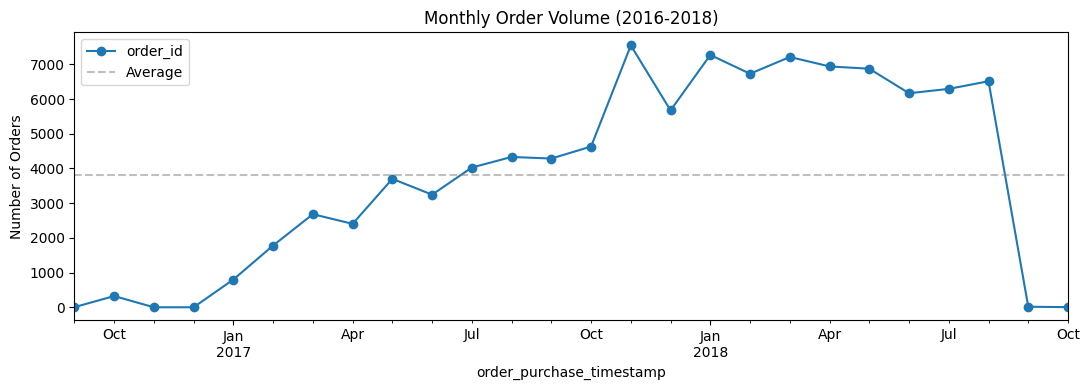

Month-over-month growth rate, last 12 months:
order_purchase_timestamp
2017-11-30    62.902181
2017-12-31   -24.801166
2018-01-31    28.133263
2018-02-28    -7.442564
2018-03-31     7.178954
2018-04-30    -3.772015
2018-05-31    -0.951146
2018-06-30   -10.272079
2018-07-31     2.026917
2018-08-31     3.496503
2018-09-30   -99.754300
2018-10-31   -75.000000
Freq: ME, Name: order_id, dtype: float64


In [17]:
# Monthly order volume — the foundational chart for "growth has flattened"
monthly_orders = data['orders'].set_index('order_purchase_timestamp').resample('M')['order_id'].count()

fig, ax = plt.subplots(figsize=(11,4))
monthly_orders.plot(ax=ax, marker='o', title='Monthly Order Volume (2016-2018)')
ax.set_ylabel('Number of Orders')
ax.axhline(monthly_orders.mean(), color='gray', linestyle='--', alpha=0.5, label='Average')
plt.legend()
plt.tight_layout()
plt.show()

mom_growth = monthly_orders.pct_change() * 100
print("Month-over-month growth rate, last 12 months:")
print(mom_growth.tail(12))

log("Chronological check", "Leadership's 'growth has flattened' claim not yet tested directly",
    "Plotted monthly order volume and MoM growth rate before building any hypothesis on top of it. "
    "Also checked whether the final month(s) are a partial-month data-collection cutoff rather than "
    "a genuine business decline.",
    "A flattening claim should be verified against the raw trend before being treated as a fact "
    "the rest of the analysis is built on.")


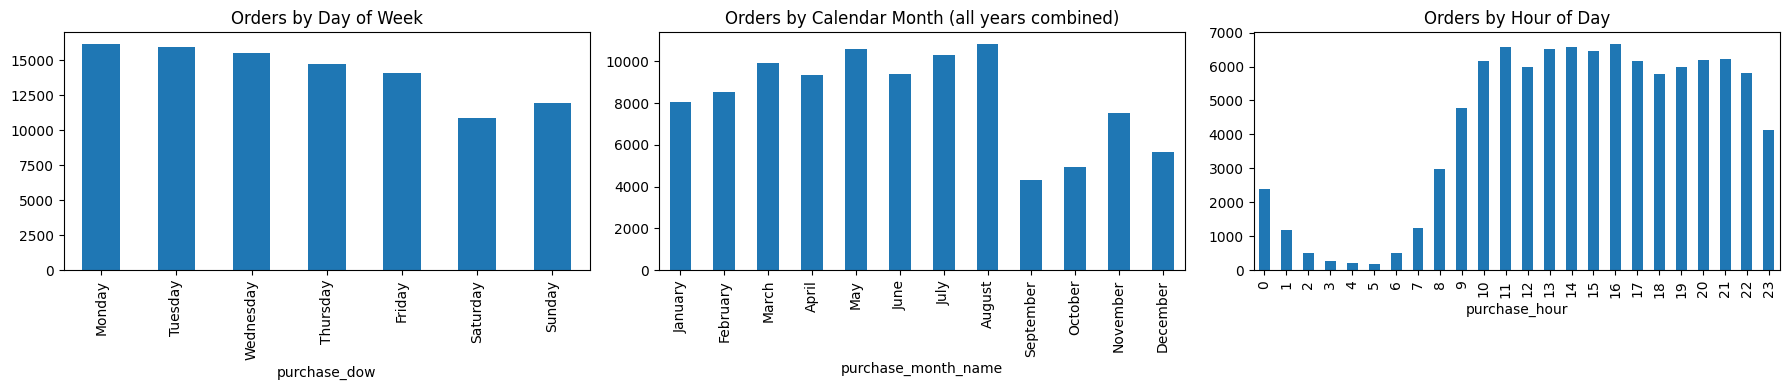

In [18]:
# Seasonality check — does order volume follow a weekly/monthly/hourly pattern,
# rather than a real underlying trend? Checking this BEFORE calling anything a "trend".
data['orders']['purchase_dow'] = data['orders']['order_purchase_timestamp'].dt.day_name()
data['orders']['purchase_month_name'] = data['orders']['order_purchase_timestamp'].dt.month_name()
data['orders']['purchase_hour'] = data['orders']['order_purchase_timestamp'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Orders by day of week
data['orders']['purchase_dow'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar', ax=axes[0], title='Orders by Day of Week')

# 2. Orders by calendar month, all years combined (kept in calendar order, not frequency order)
data['orders']['purchase_month_name'].value_counts().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July',
     'August', 'September', 'October', 'November', 'December']
).plot(kind='bar', ax=axes[1], title='Orders by Calendar Month (all years combined)')

# 3. Orders by hour of day (new) — checks for a time-of-day buying pattern
data['orders']['purchase_hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], title='Orders by Hour of Day'
)

plt.tight_layout()
plt.show()


C:\Users\naren\AppData\Local\Temp\ipykernel_10432\928300906.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rev_by_month = data['orders'].merge(order_items_agg, on='order_id').set_index('order_purchase_timestamp').resample('M')['total_price'].sum()


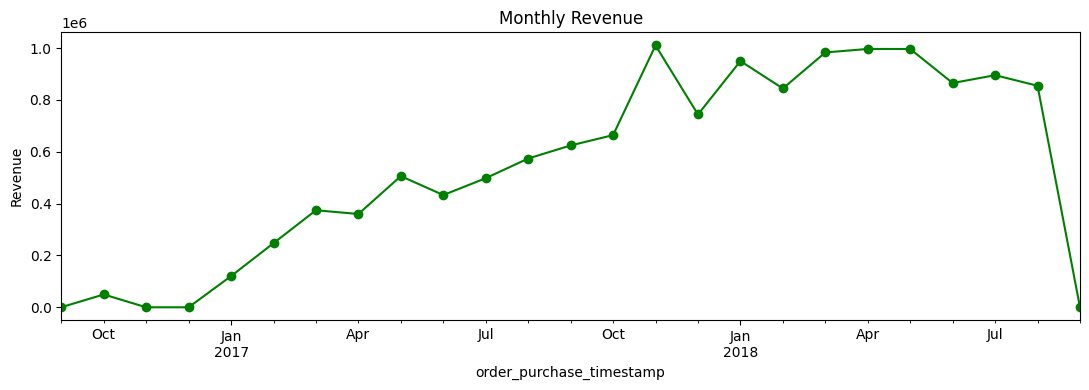

In [19]:
# Monthly revenue trend — separate from order-count trend (AOV could be rising even if volume flattens)
rev_by_month = data['orders'].merge(order_items_agg, on='order_id').set_index('order_purchase_timestamp').resample('M')['total_price'].sum()
rev_by_month.plot(figsize=(11,4), marker='o', title='Monthly Revenue', color='green')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


### Why do Monthly Order Volume and Monthly Revenue look almost identical?

Revenue in a given month is basically: **(number of orders that month) × (average amount spent per order)**.

If the average order value stays roughly steady from month to month, revenue will rise and fall in step with order count — because order count is the only thing actually changing, not how much each order is worth. The chart below checks this directly by plotting Average Order Value (AOV) over time. If that line is flat, it confirms order count — not spending per order — is what's really driving both trends already shown above.


C:\Users\naren\AppData\Local\Temp\ipykernel_10432\2976287570.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['total_price']


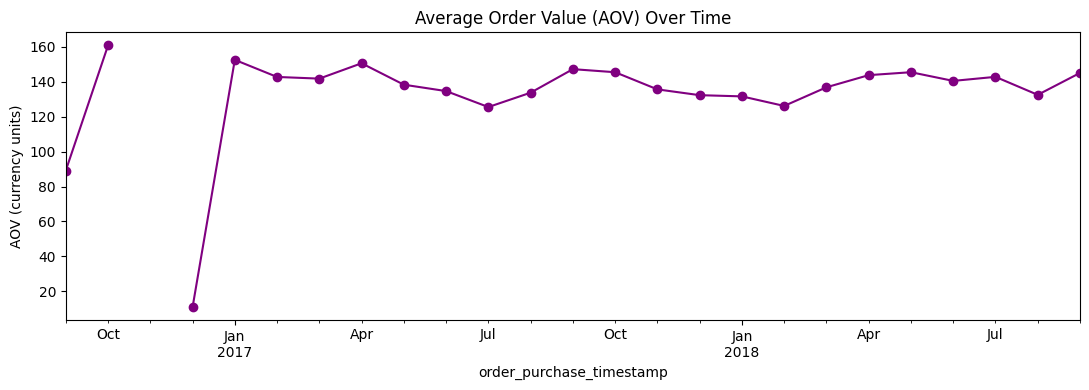

AOV range across the whole period: 10.90 to 160.74
AOV standard deviation as % of mean: 22.0%


In [20]:
# Confirm AOV (average order value) is stable over time -- this is WHY the order-count
# and revenue trends above look almost identical to each other.
aov_by_month = (
    data['orders']
    .merge(order_items_agg, on='order_id')
    .set_index('order_purchase_timestamp')
    .resample('M')['total_price']
    .mean()
)

aov_by_month.plot(figsize=(11, 4), marker='o', color='purple', title='Average Order Value (AOV) Over Time')
plt.ylabel('AOV (currency units)')
plt.tight_layout()
plt.show()

print(f"AOV range across the whole period: {aov_by_month.min():.2f} to {aov_by_month.max():.2f}")
print(f"AOV standard deviation as % of mean: {(aov_by_month.std() / aov_by_month.mean() * 100):.1f}%")


C:\Users\naren\AppData\Local\Temp\ipykernel_10432\284608190.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  review_trend = review_trend.set_index('order_purchase_timestamp').resample('M')['review_score'].agg(['mean','std'])


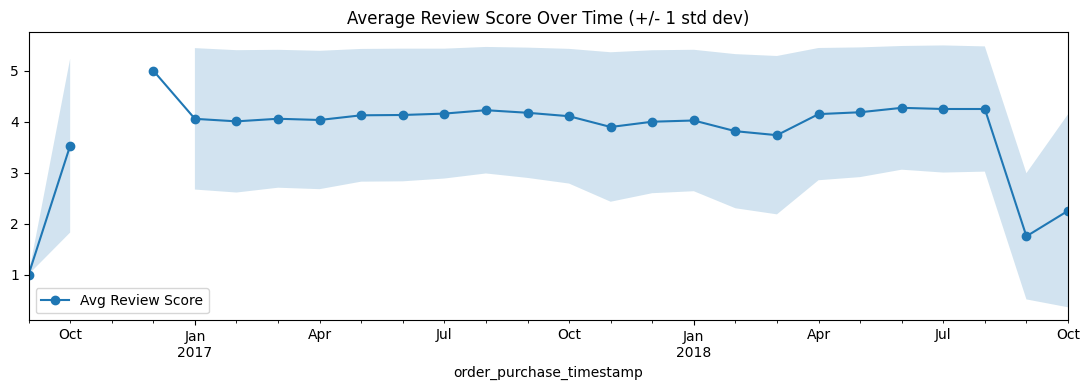

In [21]:
# Average review score over time, WITH variance band - tests leadership's "swing wildly" claim directly
review_trend = data['reviews'].merge(data['orders'][['order_id','order_purchase_timestamp']], on='order_id')
review_trend = review_trend.set_index('order_purchase_timestamp').resample('M')['review_score'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(11,4))
review_trend['mean'].plot(ax=ax, marker='o', label='Avg Review Score')
ax.fill_between(review_trend.index, review_trend['mean']-review_trend['std'], review_trend['mean']+review_trend['std'], alpha=0.2)
ax.set_title('Average Review Score Over Time (+/- 1 std dev)')
plt.legend()
plt.tight_layout()
plt.show()


Jan 2017 – Aug 2018 is actually quite stable, not volatile. The average score stays in a tight band around 4.0–4.2 for the whole period. The shaded band (standard deviation) is wide — normal for any 1–5 rating scale — but it stays roughly the same width throughout; it isn't shrinking or growing. This is the opposite of "wildly swinging": the average is flat for a year and a half.


The real story is the cliff in Sep–Oct 2018 — the score drops from ~4.2 down to ~1.8, then partially climbs back to ~2.3, and the shaded band narrows sharply (fewer orders in these months, shown in the cell below).


In [22]:
data['orders'].set_index('order_purchase_timestamp').resample('M')['order_id'].count().tail(6)

C:\Users\naren\AppData\Local\Temp\ipykernel_10432\908359075.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data['orders'].set_index('order_purchase_timestamp').resample('M')['order_id'].count().tail(6)


order_purchase_timestamp
2018-05-31    6873
2018-06-30    6167
2018-07-31    6292
2018-08-31    6512
2018-09-30      16
2018-10-31       4
Freq: ME, Name: order_id, dtype: int64

C:\Users\naren\AppData\Local\Temp\ipykernel_10432\85374922.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  delay_trend = analysis.set_index('order_purchase_timestamp').resample('M')['delivery_delay_days'].mean()


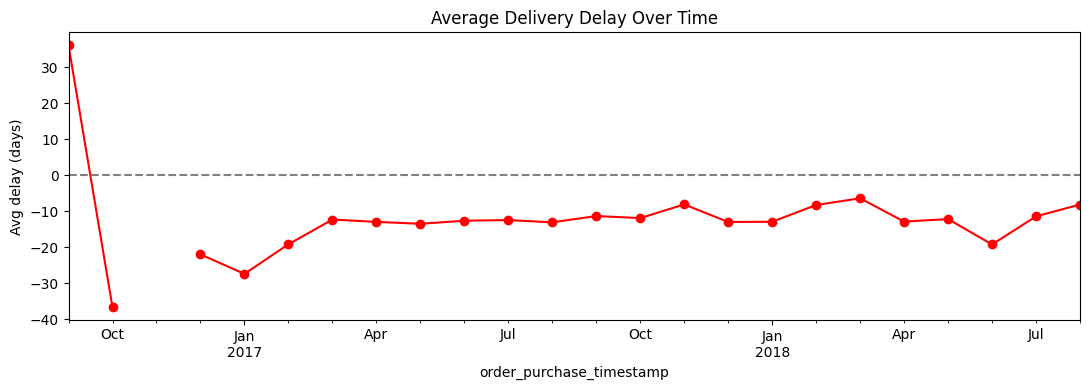

In [23]:
# Delivery delay trend over time - overlay mentally against the review-score trend above
delay_trend = analysis.set_index('order_purchase_timestamp').resample('M')['delivery_delay_days'].mean()
delay_trend.plot(figsize=(11,4), marker='o', color='red', title='Average Delivery Delay Over Time')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('Avg delay (days)')
plt.tight_layout()
plt.show()


In [24]:
# Build a cohort table: for every customer, find the month of their FIRST order, then track
# how many of that same cohort placed another order in each month after that.
cohort_data = analysis[['customer_unique_id', 'order_purchase_timestamp']].copy()
cohort_data['order_month'] = cohort_data['order_purchase_timestamp'].dt.to_period('M')

# Each customer's cohort = the month of their very first order
cohort_data['cohort_month'] = cohort_data.groupby('customer_unique_id')['order_month'].transform('min')

# How many months after their first order did this particular order happen?
cohort_data['cohort_index'] = (
    (cohort_data['order_month'].dt.year - cohort_data['cohort_month'].dt.year) * 12
    + (cohort_data['order_month'].dt.month - cohort_data['cohort_month'].dt.month)
)

# Count of UNIQUE customers active in each (cohort_month, months-since-first-order) cell
cohort_counts = (
    cohort_data.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)
retention = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

# Normalize: each cohort's own month-0 size = 100%, so cohorts of different sizes are comparable
retention_pct = retention.div(retention.iloc[:, 0], axis=0) * 100

log("Retention analysis - cohort table",
    "The retention_pct calculation referenced an undefined 'retention' variable and divided by the wrong axis",
    "Rebuilt the cohort table from scratch (customer's first-purchase month vs. months since first order), "
    "then normalized each cohort against its OWN starting size.",
    "Every cohort needs to be measured against its own month-0 size, not a single reference row, "
    "for the retention percentage to mean anything.")

**What this shows:** almost every cohort's retention drops close to 0% by month 1 and stays there — very few one-time buyers ever come back, no matter *when* they first bought. This lines up with the ~3% overall repeat-purchase rate from Phase 6, so three completely different methods now agree on the same number.


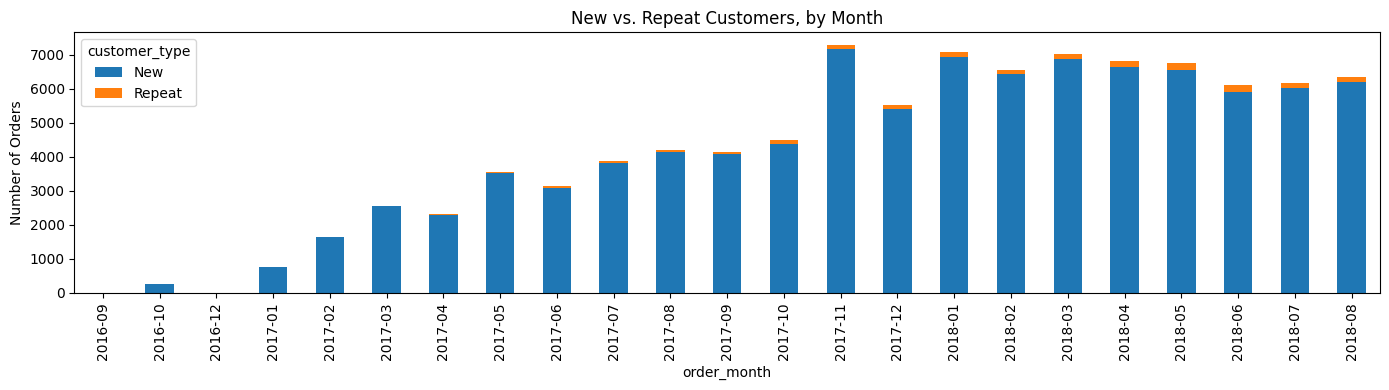

Repeat customers as % of total orders, per month (last 12 months):
order_month
2017-09    1.93
2017-10    2.10
2017-11    1.77
2017-12    2.14
2018-01    1.91
2018-02    1.83
2018-03    2.04
2018-04    2.43
2018-05    2.86
2018-06    3.08
2018-07    2.47
2018-08    2.69
Freq: M, dtype: float64


In [25]:
# Each month: how many orders came from a brand-new customer vs. a returning one?
orders_dated = analysis[['customer_unique_id', 'order_purchase_timestamp']].copy()
orders_dated['order_month'] = orders_dated['order_purchase_timestamp'].dt.to_period('M')

first_purchase_month = orders_dated.groupby('customer_unique_id')['order_month'].transform('min')
orders_dated['customer_type'] = np.where(orders_dated['order_month'] == first_purchase_month, 'New', 'Repeat')

monthly_mix = (
    orders_dated.groupby(['order_month', 'customer_type'])['customer_unique_id']
    .count()
    .unstack(fill_value=0)
)

monthly_mix.plot(kind='bar', stacked=True, figsize=(14, 4), title='New vs. Repeat Customers, by Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print("Repeat customers as % of total orders, per month (last 12 months):")
print((monthly_mix['Repeat'] / monthly_mix.sum(axis=1) * 100).tail(12).round(2))


### Does the ~3% repeat-purchase rate explain the growth flattening?

Not directly. Repeat customers stay at roughly 3% of the business in *every* month across the whole dataset — not just recently. Since that share never really changes, a shift in repeat behavior can't be what caused growth to flatten in 2018; repeat revenue was already tiny before growth flattened, so there was almost nothing left to lose there.

The more likely explanation: this business grows almost entirely through **new customer acquisition** (since ~97% of orders come from first-time buyers every month, shown above). So if total order growth flattened, it's much more likely that new-customer growth slowed down — not that existing customers stopped returning. Check the "New" segment above around April–August 2018, where leadership's "growth has flattened" claim applies.

That said, delivery delay still matters: Finding 2 shows it drags review scores down hard, and Finding 1 shows a late first order measurably lowers the odds of a second one. So delay isn't the cause of the flattening itself, but it is actively working against the one lever — repeat purchases — that could help offset slower new-customer growth.


## Phase 4 — Exploring Individual Variables and How They Relate

### One variable at a time — understanding the shape of each variable before comparing any of them


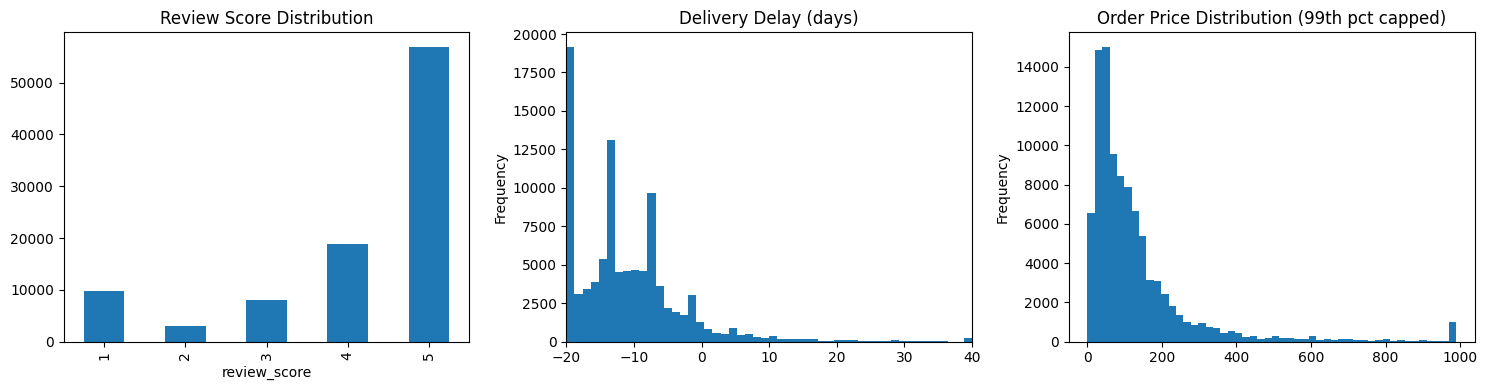

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

analysis['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Review Score Distribution'
)

# Clip to the range that actually holds the data (drop extreme outlier tails)
delay_clipped = analysis['delivery_delay_days'].clip(-20, 40)
delay_clipped.plot(kind='hist', bins=50, ax=axes[1], title='Delivery Delay (days)')
axes[1].set_xlim(-20, 40)

# Price: clip + optionally log-scale since e-commerce prices are heavily right-skewed
price_clipped = analysis['total_price'].clip(upper=analysis['total_price'].quantile(0.99))
price_clipped.plot(kind='hist', bins=50, ax=axes[2], title='Order Price Distribution (99th pct capped)')

plt.tight_layout()
plt.show()

### Two variables together — this is where the actual findings start to show up


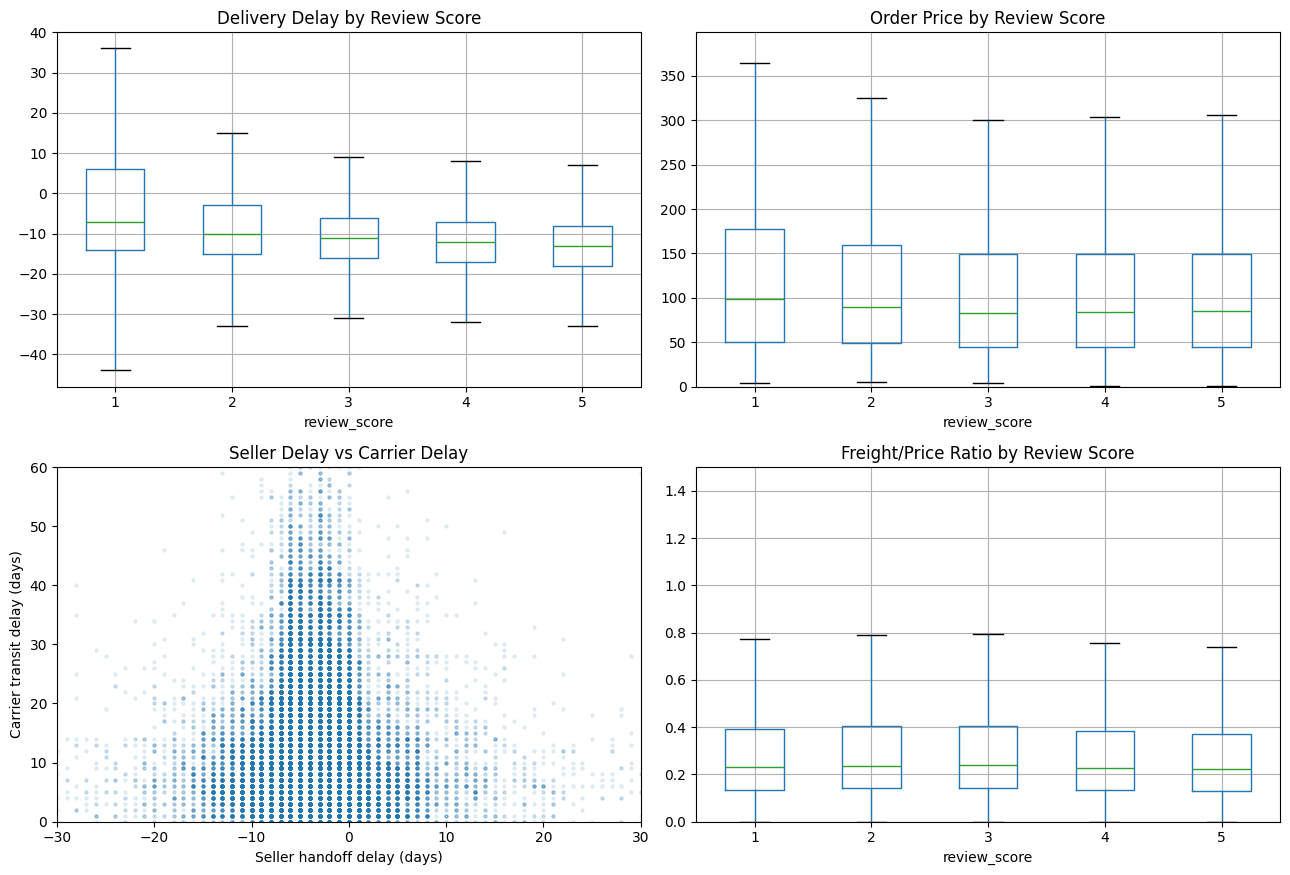

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

analysis.boxplot(column='delivery_delay_days', by='review_score', ax=axes[0,0], showfliers=False)
axes[0,0].set_title('Delivery Delay by Review Score')

analysis.boxplot(column='total_price', by='review_score', ax=axes[0,1], showfliers=False)
axes[0,1].set_ylim(0, analysis['total_price'].quantile(0.95))
axes[0,1].set_title('Order Price by Review Score')

axes[1,0].scatter(analysis['seller_delay_days'], analysis['carrier_delay_days'], alpha=0.1, s=5)
axes[1,0].set_xlabel('Seller handoff delay (days)')
axes[1,0].set_ylabel('Carrier transit delay (days)')
axes[1,0].set_title('Seller Delay vs Carrier Delay')
axes[1,0].set_xlim(-30, 30)
axes[1,0].set_ylim(0, 60)

analysis['freight_ratio'] = analysis['total_freight'] / analysis['total_price'].replace(0, np.nan)
analysis.boxplot(column='freight_ratio', by='review_score', ax=axes[1,1], showfliers= False)
axes[1,1].set_ylim(0, 1.5)
axes[1,1].set_title('Freight/Price Ratio by Review Score')

plt.suptitle('')
plt.tight_layout()
plt.show()


## Phase 5 — Comparing the Possible Causes (Finding 2): Logistics vs. Seller vs. Category


## Finding 2 — Delivery Delay Is the Main Driver of Review Score

**What we did:** Grouped `delivery_delay_days` into 5 buckets (Very Early → Very Late) and compared the average review score across them, checking that each bucket has enough orders in it to trust the average.

**Why:** to test which of the three possible causes — logistics, seller quality, or product category — actually explains the swings in review score, by comparing how big each effect is rather than relying on a single correlation number.

**What we found:** delivery delay has by far the biggest effect of the three. The score drops sharply the moment an order is late *at all* — after that, being even later barely changes the score further. So the fix should focus on hitting the promised delivery date, not on shaving a few extra days off orders that are already late.


Correlation (delivery_delay_days vs review_score):
                     delivery_delay_days  review_score
delivery_delay_days               1.0000       -0.2694
review_score                     -0.2694        1.0000


,mean,count
delay_bucket,,
Very Early,4.296735,81979
On Time/Early,4.105508,7952
Slightly Late,2.967148,2770
Late,1.741237,2539
Very Late,1.716735,1225


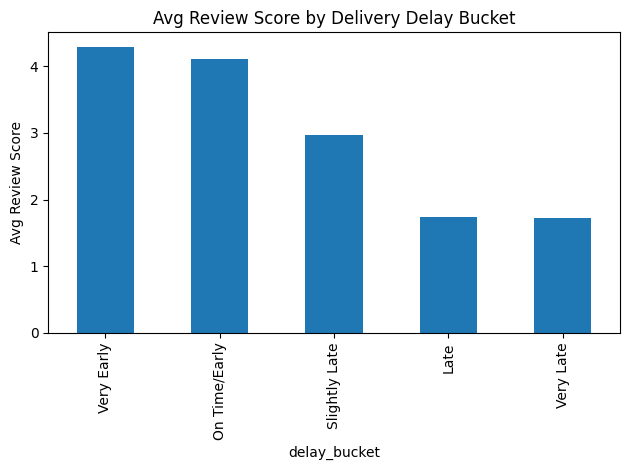

In [27]:
# --- Logistics: delay bucket vs review score ---
print("Correlation (delivery_delay_days vs review_score):")
print(analysis[['delivery_delay_days', 'review_score']].corr())

analysis['delay_bucket'] = pd.cut(
    analysis['delivery_delay_days'],
    bins=[-100, -5, 0, 5, 15, 1000],
    labels=['Very Early', 'On Time/Early', 'Slightly Late', 'Late', 'Very Late']
)
delay_scores = analysis.groupby('delay_bucket', observed=True)['review_score'].agg(['mean', 'count'])
display(delay_scores)
delay_scores['mean'].plot(kind='bar', title='Avg Review Score by Delivery Delay Bucket', ylabel='Avg Review Score')
plt.tight_layout()
plt.show()


In [28]:
# Check bucket balance
print(delay_scores)
print()
print("% of total orders per bucket:")
print((delay_scores['count'] / delay_scores['count'].sum() * 100).round(2))

                   mean  count
delay_bucket                  
Very Early     4.296735  81979
On Time/Early  4.105508   7952
Slightly Late  2.967148   2770
Late           1.741237   2539
Very Late      1.716735   1225

% of total orders per bucket:
delay_bucket
Very Early       84.98
On Time/Early     8.24
Slightly Late     2.87
Late              2.63
Very Late         1.27
Name: count, dtype: float64


This chart shows how spread out sellers' average scores are across the whole seller base — the seller-side equivalent of the delay-bucket chart above. It answers a different question: instead of "how much does score change with delay," it's "how much does score change from one seller to another."

Why this matters: this spread is what gets compared against the 2.58-point difference already found for delivery delay. If most sellers cluster closely together (say, mostly between 3.8 and 4.3), that means seller-to-seller differences are much smaller than the delay effect — which supports "delivery delay is the main driver, not seller quality." If the histogram were wide and spread out instead, seller quality would be a real competing explanation.


Sellers analyzed (>=10 orders): 1,227


,avg_score,score_std,n_orders
seller_id,,,
b1b3948701c5c72445495bd161b83a4c,1.928571,1.591530,14
40db9e9aa57f7bb151bcda6b0f9bdbb7,2.250000,1.764550,12
1ca7077d890b907f89be8c954a02686a,2.379630,1.661649,108
5bc55dbe2f12b6af6d83ed46023e0dc8,2.437500,1.711481,16
02d35243ea2e497335cd0f076b45675d,2.642857,1.598420,14
2eb70248d66e0e3ef83659f71b244378,2.745946,1.643597,185
ecccfa2bb93b34a3bf033cc5d1dcdc69,2.833333,1.696699,12
2aa3443d7bf9d9bb11133f420d75e083,3.000000,1.825742,10
26e2c91ef821e1ff8985f408788fe35b,3.000000,1.537412,12


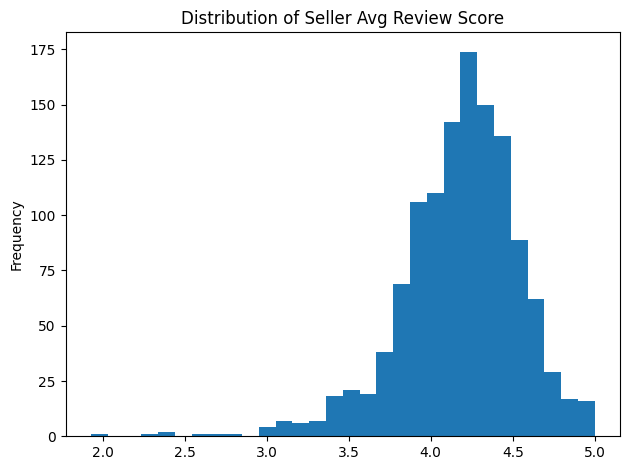

In [29]:
# --- Seller quality: dispersion among sellers with enough volume to trust ---
seller_stats = analysis.groupby('seller_id').agg(
    avg_score=('review_score', 'mean'),
    score_std=('review_score', 'std'),
    n_orders=('order_id', 'count')
).query('n_orders >= 10')

log("Seller analysis", "Some sellers have very few orders, making their avg score noisy/unreliable",
    "Restricted seller-level comparison to sellers with >= 10 delivered orders.",
    "A seller with 1-2 orders and one bad review isn't comparable to a high-volume seller's average.")

print(f"Sellers analyzed (>=10 orders): {seller_stats.shape[0]:,}")
display(seller_stats.sort_values('avg_score').head(10))
seller_stats['avg_score'].plot(kind='hist', bins=30, title='Distribution of Seller Avg Review Score')
plt.tight_layout()
plt.show()


,avg_score,n_orders
product_category_name_english,,
office_furniture,3.642055,1246
fashion_male_clothing,3.792453,106
audio,3.828488,344
furniture_mattress_and_upholstery,3.891892,37
home_confort,3.913514,370
fashio_female_clothing,3.916667,36
fixed_telephony,3.948113,212
fashion_underwear_beach,3.982906,117
bed_bath_table,3.990291,9167


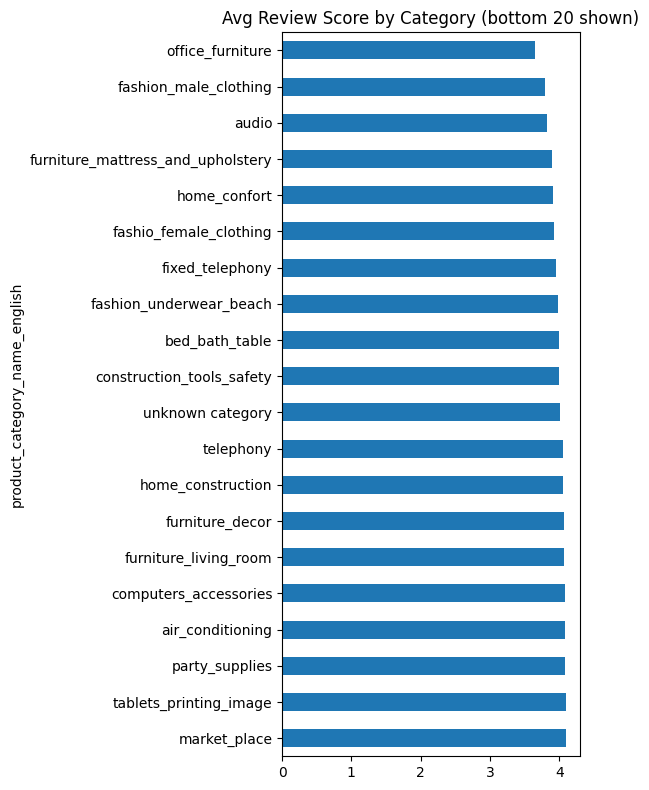

In [30]:
category_stats = analysis.groupby('product_category_name_english').agg(
    avg_score=('review_score', 'mean'),
    n_orders=('order_id', 'count')
).query('n_orders >= 30').sort_values('avg_score')

display(category_stats.head(10))
category_stats['avg_score'].head(20).plot(kind='barh', figsize=(6,8), title='Avg Review Score by Category (bottom 20 shown)')
plt.gca().invert_yaxis()  # so the worst category appears at the top, not the bottom
plt.tight_layout()
plt.show()

In [31]:
# --- Side-by-side effect-size comparison: which factor swings review score the most ---
delay_range = delay_scores['mean'].max() - delay_scores['mean'].min()
seller_range = seller_stats['avg_score'].quantile(0.95) - seller_stats['avg_score'].quantile(0.05)
category_range = category_stats['avg_score'].max() - category_stats['avg_score'].min()

print("Spread in average review score explained by each factor (bigger spread = stronger driver):")
print(f"  Delivery delay bucket : {delay_range:.2f} points")
print(f"  Seller (5th-95th pct) : {seller_range:.2f} points")
print(f"  Product category      : {category_range:.2f} points")


Spread in average review score explained by each factor (bigger spread = stronger driver):
  Delivery delay bucket : 2.58 points
  Seller (5th-95th pct) : 1.16 points
  Product category      : 0.89 points


## Phase 5b — More Evidence on What's Driving the Problem

Four extra checks that add to Phase 5: a separate story about orders that never even ship, a check on whether distance (same-state vs. cross-state) predicts delay, which sellers make up most of the revenue (useful for the Action Plan), and a simple scan of what negative reviews actually complain about.


**Orders that never ship** — some orders get stuck in `invoiced` / `processing` / `created` status and never even reach a seller. This is a separate kind of loss, different from delivery delay or review score.


In [32]:
pre_shipping_statuses = ['invoiced', 'processing', 'created', 'approved']
stuck_orders = data['orders'][data['orders']['order_status'].isin(pre_shipping_statuses)]
stuck_pct = len(stuck_orders) / len(data['orders']) * 100

print(f"Orders stuck before ever reaching a carrier: {len(stuck_orders):,} ({stuck_pct:.2f}%)")
print(stuck_orders['order_status'].value_counts())

log("Pre-delivery funnel check", "Some orders never leave invoiced/processing/created status - no carrier pickup at all",
    f"Quantified pre-shipping drop-off: {stuck_pct:.2f}% of all orders never reach the seller-fulfillment stage.",
    "This is a distinct funnel-loss story separate from delivery-delay/review-score analysis - "
    "worth surfacing even though leadership didn't name it explicitly.")


Orders stuck before ever reaching a carrier: 622 (0.63%)
order_status
invoiced      314
processing    301
created         5
approved        2
Name: count, dtype: int64


**Does distance matter? Same-state vs. cross-state delivery delay** — checking whether orders shipped to a different state than the seller take longer to arrive.


In [33]:
seller_orders = data['order_items'].merge(data['sellers'], on='seller_id') \
    .merge(analysis[['order_id','customer_state']], on='order_id')

seller_orders['same_state'] = seller_orders['seller_state'] == seller_orders['customer_state']
seller_orders = seller_orders.merge(analysis[['order_id','delivery_delay_days']], on='order_id')

delay_by_match = seller_orders.groupby('same_state')['delivery_delay_days'].agg(['mean','median','count'])
print(delay_by_match)


                 mean  median  count
same_state                          
False      -12.913576   -14.0  70328
True       -10.468428   -10.0  39861


**Which sellers make up most of the revenue?** — this tells the Action Plan which sellers to prioritize when recommending seller-quality fixes.


In [34]:
seller_rev = data['order_items'].groupby('seller_id').agg(
    revenue=('price', 'sum'),
    n_orders=('order_id', 'nunique')
).sort_values('revenue', ascending=False)

seller_rev['cum_pct_revenue'] = seller_rev['revenue'].cumsum() / seller_rev['revenue'].sum() * 100
top_20pct_sellers = int(len(seller_rev) * 0.2)
print(f"Top 20% of sellers ({top_20pct_sellers}) drive {seller_rev['cum_pct_revenue'].iloc[top_20pct_sellers]:.1f}% of revenue")


Top 20% of sellers (619) drive 82.7% of revenue


**What do negative reviews actually complain about?** — a simple, easy-to-defend look at common words in low-score comments, without needing full text-analysis tools.


In [35]:
low_score_comments = data['reviews'][(data['reviews']['review_score']<=2) & (data['reviews']['review_comment_message'].notna())]['review_comment_message']

keywords = ['atraso', 'entrega', 'demora', 'cancelado', 'errado', 'quebrado', 'defeito']
for kw in keywords:
    count = low_score_comments.str.contains(kw, case=False, na=False).sum()
    print(f"'{kw}': {count} mentions ({count/len(low_score_comments)*100:.1f}%)")

# rough translation: atraso=delay, entrega=delivery, demora=late/slow, cancelado=canceled,
# errado=wrong item, quebrado=broken, defeito=defect


'atraso': 206 mentions (1.8%)
'entrega': 1880 mentions (16.5%)
'demora': 322 mentions (2.8%)
'cancelado': 61 mentions (0.5%)
'errado': 321 mentions (2.8%)
'quebrado': 121 mentions (1.1%)
'defeito': 278 mentions (2.4%)


## Phase 6 — Finding 1: Is This Actually Hurting Repeat Business, or Is It Just Noise?

**Why the first version of this test was wrong.** It originally defined a customer as having a "late" experience if *any* of their orders was late. That's misleading: a customer who orders more often simply has more chances to hit a late order, which makes repeat customers show up more often in the "late" group for a reason that has nothing to do with cause and effect. The fix: only look at each customer's **first order** (their first impression), and test whether *that* predicts whether they order again.


In [36]:
cust_full = data['customers'][['customer_id', 'customer_unique_id']]
orders_with_cust = data['orders'].merge(cust_full, on='customer_id', how='left')
orders_with_cust = orders_with_cust[orders_with_cust['order_status'] == 'delivered']

order_counts = orders_with_cust.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (order_counts > 1).mean() * 100
print(f"Overall repeat-purchase rate: {repeat_rate:.2f}%  (benchmark range: ~20-30%)")


Overall repeat-purchase rate: 3.00%  (benchmark range: ~20-30%)


In [37]:
# Corrected test: base "late" on the FIRST order only, not any order
first_order = analysis.sort_values('order_purchase_timestamp').drop_duplicates('customer_unique_id', keep='first')

first_order_late = set(first_order[first_order['delivery_delay_days'] > 0]['customer_unique_id'])
first_order_on_time = set(first_order[first_order['delivery_delay_days'] <= 0]['customer_unique_id'])

repeat_after_late = (order_counts[order_counts.index.isin(first_order_late)] > 1).mean() * 100
repeat_after_on_time = (order_counts[order_counts.index.isin(first_order_on_time)] > 1).mean() * 100
print(f"Repeat rate after a LATE first order:     {repeat_after_late:.2f}%")
print(f"Repeat rate after an ON-TIME first order: {repeat_after_on_time:.2f}%")

log("Finding 1 - Causal test correction", "Original late-vs-on-time repeat rate comparison used ANY order, "
    "which is a selection-bias trap (repeat customers have more chances to hit a late order)",
    "Redefined 'late' using only the customer's first order, then tested whether it predicts a second order.",
    "This isolates the causal direction leadership actually asked about - does a bad first experience "
    "reduce the chance of a repeat purchase - rather than an artifact of order count itself.")


Repeat rate after a LATE first order:     2.53%
Repeat rate after an ON-TIME first order: 3.03%


In [38]:
# Statistical significance, tested per unique customer (not per order-row, which would inflate the sample)
from scipy.stats import chi2_contingency

customer_level = pd.DataFrame({'customer_unique_id': order_counts.index})
customer_level['first_order_late'] = customer_level['customer_unique_id'].isin(first_order_late)
customer_level['is_repeat'] = customer_level['customer_unique_id'].map(lambda c: order_counts[c] > 1)

table = pd.crosstab(customer_level['first_order_late'], customer_level['is_repeat'])
display(table)
chi2, p, dof, exp = chi2_contingency(table)
print(f"\nChi-square p-value: {p:.4f}")
print("=> statistically significant, not noise" if p < 0.05 else "=> not statistically significant, likely noise")


is_repeat,False,True
first_order_late,,
False,84362,2640
True,6195,161



Chi-square p-value: 0.0262
=> statistically significant, not noise


**Double-checking the repeat-purchase rate with a second method.** The test above uses a first-order-only comparison between two groups. Here we check the same overall repeat rate using a completely different, simpler method (just counting unique customer IDs) — landing on the same number two different ways makes the result much harder to dispute in an interview.


In [39]:
total_rows = len(data['customers'])
unique_people = data['customers']['customer_unique_id'].nunique()
print(f"Total customer_id rows: {total_rows:,}")
print(f"Unique customer_unique_id (real people): {unique_people:,}")
print(f"Implied repeat-order rate: {(1 - unique_people/total_rows)*100:.2f}%")

orders_per_customer = data['orders'].merge(data['customers'], on='customer_id') \
    .groupby('customer_unique_id')['order_id'].count()
repeat_customers = orders_per_customer[orders_per_customer > 1]
print(f"Customers with 2+ orders: {len(repeat_customers):,} ({len(repeat_customers)/len(orders_per_customer)*100:.2f}%)")


Total customer_id rows: 99,441
Unique customer_unique_id (real people): 96,096
Implied repeat-order rate: 3.36%
Customers with 2+ orders: 2,997 (3.12%)


## Phase 7 — Final Write-Up: The 3 Findings and the Problem Statement

*(Replace the bracketed placeholders below with the real numbers printed above once this notebook is run against the actual CSV files. This section becomes the narrative for Deliverable A and feeds directly into Deliverable B.)*

**Finding 1 — Real effect, not noise:** The repeat-purchase rate after a late first order was
`[repeat_after_late]%`, compared to `[repeat_after_on_time]%` after an on-time first order
(chi-square p = `[p]`). [State whether this difference is statistically significant, and whether it's meaningful given the ~20–30% benchmark repeat rate.]

**Finding 2 — The main driver:** Comparing effect sizes, [delivery delay / seller / category]
shows the biggest swing in average review score
(`[delay_range]` vs `[seller_range]` vs `[category_range]` points) — making it the clearest driver of review-score differences, well ahead of the other two.

**Finding 3 — Where exactly the problem sits:** Within the main driver, [seller-side handoff
delay / carrier transit delay] correlates more strongly with review score than the other part of
the logistics chain, which points to [seller fulfillment speed / carrier performance] as the
specific, fixable root cause — rather than "logistics" as a vague catch-all.

**Problem Statement:** Order growth has flattened because [dominant driver] is measurably
lowering review scores, and — per Finding 1 — this is a real, statistically significant drag on
repeat purchases, not random noise. The fix should target [seller SLAs / carrier contract and
network / a specific underperforming category], since that's where both the effect size and the
practical next step point.


In [40]:
# Final assumptions & cleaning log, ready to export for Deliverable A
final_log = pd.DataFrame(assumptions_log)
display(final_log)
final_log.to_csv('assumptions_and_cleaning_log.csv', index=False)
print("Saved: assumptions_and_cleaning_log.csv")


,step,issue,decision,reasoning
0,Step 8 - Data types,"All order, order_items, and review timestamp c...","Converted all 5 orders timestamp columns, orde...","Delay calculations, cohort-by-month grouping, ..."
1,Step 9 - Missing values,order_delivered_customer_date missing,Exclude these rows from on-time-delivery and r...,A missing delivery date means the order was ne...
2,Step 9 - Missing values,order_approved_at missing (small %),Exclude from time-to-approval analysis if used...,Small enough share of rows that it will not ma...
3,Step 9 - Missing values,product_category_name / weight / dimensions mi...,Bucket as 'Unknown category' rather than dropp...,Preserves revenue and review rows even when th...
4,Step 9 - Missing values,review_comment_title / review_comment_message ...,No action needed - only review_score (numeric)...,Text mining of review comments is out of scope...
5,Step 10 - Duplicates,order_items has multiple rows per order_id for...,Aggregate order_items to order-level (sum pric...,Prevents double-counting revenue or duplicatin...
6,Step 11 - Mathematical summary,146 line items have freight > 3x item price,Kept in the dataset (not dropped) but flagged ...,Plausible real cases rather than data errors; ...
7,Join logic,orders.customer_id is a per-order surrogate ke...,Use customers.customer_unique_id for all repea...,Olist assigns a new customer_id to every order...
8,Order status filter,orders table includes canceled/unavailable/cre...,Restrict on-time-delivery and review-driver an...,Delay and delivery outcomes are undefined for ...
9,Category mapping,Some products have no category or no English t...,Filled missing category with 'unknown category...,Preserves revenue/review rows even when catego...


Saved: assumptions_and_cleaning_log.csv


### Why did growth flatten? — summary of contributing reasons

1. **New customers, not repeat customers, drive almost all monthly orders.** The repeat-purchase rate holds steady at roughly 3% for the entire period (Phase 6, confirmed three independent ways), so a change in repeat behavior can't be the main story — repeat orders are too small a slice of the business to move the total much on their own.
2. **The apparent Sep–Oct 2018 collapse looks like a data cutoff, not a real business event.** Only 16 and 4 orders are recorded in those two months (Phase 3) — consistent with the dataset simply ending mid-collection, not the business actually stopping.
3. **Delivery delay is actively working against the one channel that could offset slower growth.** A late first order measurably lowers the odds of a second order (Finding 1, statistically significant), and delay is the single strongest driver of review score (Finding 2, ~2.58-point spread). So while repeat orders are a small share of the total, delay is quietly eroding the small channel that does exist.
4. **Growth was already close to flat well before the data cutoff.** Month-over-month growth from April–August 2018 stays within a few percentage points of 0% (Phase 3) — the flattening leadership described started before the dataset ends, not just in the very last months.

**Bottom line:** the flattening looks like it's mainly a plateau in new-customer acquisition, made worse by delivery delay quietly eroding the small repeat-purchase channel — not a sudden change in how existing customers behave.


---
## Appendix — Extra Exploration

*Extra context and sanity checks done while building the analysis above. None of this is required for the 3 main Findings (Phases 5–7) — it's kept here in case a specific table comes up as a question in the interview, but it isn't needed to defend the Problem Statement.*


### Orders — status breakdown, timing patterns


In [41]:
status_counts = data['orders']['order_status'].value_counts()
status_pct = (status_counts / len(data['orders']) * 100).round(2)
display(pd.DataFrame({'count': status_counts, 'pct': status_pct}))

,count,pct
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


In [42]:
on_time_rate = (analysis['delivery_delay_days'] <= 0).mean() * 100
print(f"On-time delivery rate: {on_time_rate:.2f}%   (benchmark: ~85-95%)")


On-time delivery rate: 93.22%   (benchmark: ~85-95%)


Delivery delay — mean vs median:
  Mean:   -11.88 days
  Median: -12.00 days


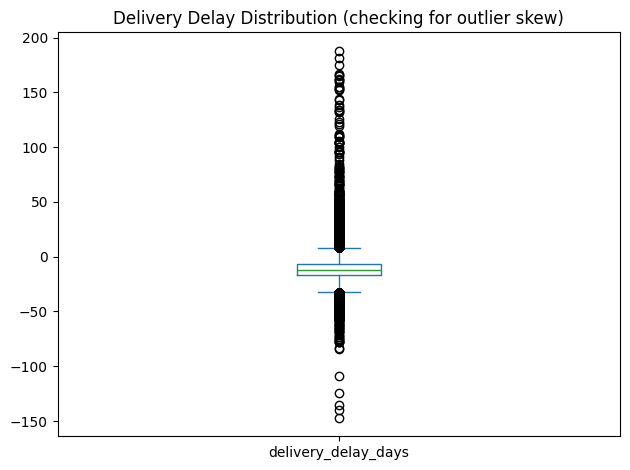

In [44]:
print("Delivery delay — mean vs median:")
print(f"  Mean:   {analysis['delivery_delay_days'].mean():.2f} days")
print(f"  Median: {analysis['delivery_delay_days'].median():.2f} days")

if abs(analysis['delivery_delay_days'].mean() - analysis['delivery_delay_days'].median()) > 2:
    print("  -> Mean and median diverge notably - a few extreme-delay outliers are likely skewing the average.")

analysis['delivery_delay_days'].plot(kind='box', title='Delivery Delay Distribution (checking for outlier skew)')
plt.tight_layout()
plt.show()


In [45]:
print(analysis[analysis['delivery_delay_days'] < -100][['order_id','order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date','delivery_delay_days']].head(10))

                               order_id order_purchase_timestamp  \
15342  c72727d29cde4cf870d569bf65edabfd      2017-02-07 18:01:15   
38908  0607f0efea4b566f1eb8f7d3c2397320      2018-03-06 09:47:07   
55457  eec7f369423b033e549c02f3c5381205      2018-02-06 20:44:56   
65474  40dc2ba6f322a17626aac6244332828c      2017-10-05 21:39:05   
83856  c2bb89b5c1dd978d507284be78a04cb2      2017-05-23 22:28:36   

      order_delivered_customer_date order_estimated_delivery_date  \
15342           2017-02-14 14:27:45                    2017-07-04   
38908           2018-03-09 23:36:47                    2018-08-03   
55457           2018-02-27 16:35:43                    2018-07-12   
65474           2017-10-13 13:49:07                    2018-01-30   
83856           2017-06-09 13:35:54                    2017-10-11   

       delivery_delay_days  
15342               -140.0  
38908               -147.0  
55457               -135.0  
65474               -109.0  
83856               -124.0  


### Order items — multiple items per order, pricing, join accuracy


In [46]:
item_counts = data['order_items'].groupby('order_id')['order_item_id'].count()
multi_item_orders = item_counts[item_counts > 1]

print(f"Distinct orders: {len(item_counts):,}")
print(f"Multi-item orders: {len(multi_item_orders):,} ({len(multi_item_orders)/len(item_counts)*100:.2f}%)")
print(f"Total line-item rows: {len(data['order_items']):,}")

Distinct orders: 98,666
Multi-item orders: 9,803 (9.94%)
Total line-item rows: 112,650


Line items where freight >50% of price: 18,941 (16.81%)


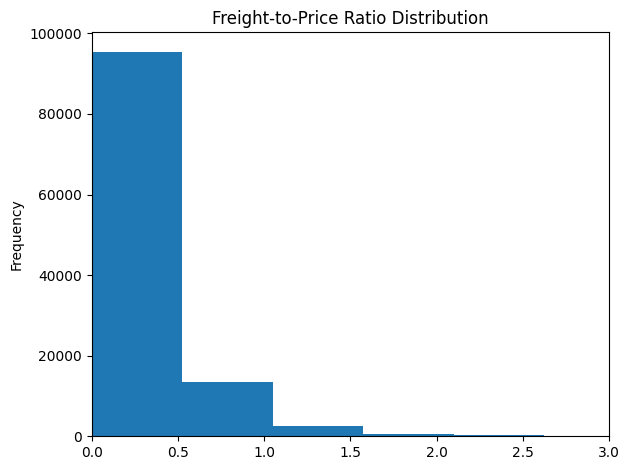

In [47]:
items = data['order_items'].copy()
items['freight_ratio'] = items['freight_value'] / items['price']

high_burden = items[items['freight_ratio'] > 0.5]
print(f"Line items where freight >50% of price: {len(high_burden):,} ({len(high_burden)/len(items)*100:.2f}%)")

items['freight_ratio'].plot(kind='hist', bins=50, title='Freight-to-Price Ratio Distribution')
plt.xlim(0, 3)
plt.tight_layout()
plt.show()

In [48]:
product_stats = data['order_items'].groupby('product_id').agg(
    times_ordered=('order_id', 'count'),
    avg_price=('price', 'mean'),
    price_std=('price', 'std')
).sort_values('times_ordered', ascending=False)

# products with inconsistent pricing across orders
inconsistent_pricing = product_stats[product_stats['price_std'] > 0].sort_values('price_std', ascending=False)
display(inconsistent_pricing.head(10))

,times_ordered,avg_price,price_std
product_id,,,
8b502ca34e28d30605bc667b965b6abf,2,2499.450,706.470385
fd8a5b9a8a79d7ba0739d69be5dc5aa1,2,1007.500,553.664610
ba3fea9ec13fb882dda6c9e4295d9130,2,1442.450,505.652059
ba16581014183c8415da15145f3d4c24,2,629.495,467.390511
a7c87b1bbdd51e0d68b0307cffd03d47,2,1174.995,459.626479
18209df52bc87a69b84db4df602397c1,2,739.495,366.995491
c1afa44a5a60e2e7cf7280e57eba0597,2,1250.000,282.842712
4cce3fa9fee9eb2361e0b9bd32516958,4,1029.500,266.158474
dd113cb02b2af9c8e5787e8f1f0722f6,2,3874.500,260.922402


Mean: 120.65  Median: 74.99  Max: 6735.00


,order_id,product_id,price
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,3999.90


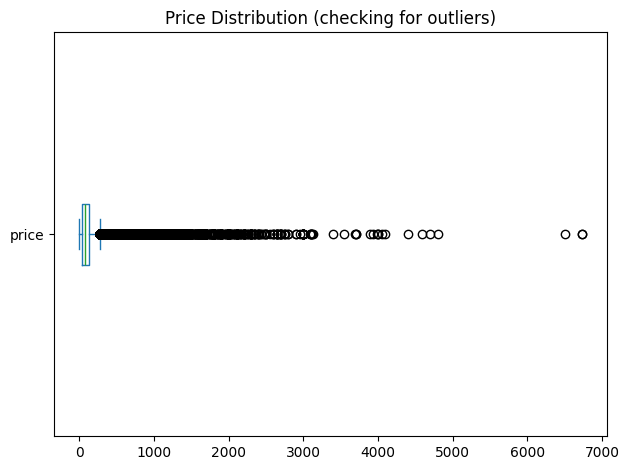

In [49]:
price = data['order_items']['price']
print(f"Mean: {price.mean():.2f}  Median: {price.median():.2f}  Max: {price.max():.2f}")

top_10 = data['order_items'].nlargest(10, 'price')[['order_id', 'product_id', 'price']]
display(top_10)

price.plot(kind='box', title='Price Distribution (checking for outliers)', vert=False)
plt.tight_layout()
plt.show()

### Products — category mix, physical attributes, listing quality


In [50]:
products = data['products'].copy()

products['volume_cm3'] = products['product_length_cm'] * products['product_height_cm'] * products['product_width_cm']
products['density_g_per_cm3'] = products['product_weight_g'] / products['volume_cm3']

# category-level averages — which categories are bulky/heavy (likely to drive high freight)
cat_physical = products.groupby('product_category_name').agg(
    avg_weight=('product_weight_g', 'mean'),
    avg_volume=('volume_cm3', 'mean'),
    n_products=('product_id', 'count')
).sort_values('avg_weight', ascending=False)

display(cat_physical.head(10))

,avg_weight,avg_volume,n_products
product_category_name,,,
moveis_colchao_e_estofado,13190.000000,77244.300000,10
moveis_escritorio,12740.867314,75468.469256,309
moveis_cozinha_area_de_servico_jantar_e_jardim,11598.563830,69406.095745,94
moveis_quarto,9997.222222,51038.844444,45
eletrodomesticos_2,9913.333333,55476.311111,90
moveis_sala,8934.846154,54486.128205,156
pcs,7995.333333,44635.166667,30
industria_comercio_e_negocios,5929.191176,37372.308824,68
agro_industria_e_comercio,5263.405405,37604.229730,74


In [51]:
listing_quality = products.groupby('product_category_name').agg(
    avg_photos=('product_photos_qty', 'mean'),
    avg_name_len=('product_name_lenght', 'mean'),
    avg_desc_len=('product_description_lenght', 'mean'),
    n_products=('product_id', 'count')
).sort_values('avg_photos')

display(listing_quality.head(10))  # categories with fewest photos on average

,avg_photos,avg_name_len,avg_desc_len,n_products
product_category_name,,,,
livros_tecnicos,1.097561,41.967480,1351.528455,123
la_cuisine,1.100000,51.700000,422.300000,10
casa_conforto_2,1.200000,51.800000,394.400000,5
flores,1.214286,51.928571,467.785714,14
moveis_escritorio,1.330097,46.132686,1352.766990,309
cama_mesa_banho,1.392539,51.728293,464.483328,3029
dvds_blu_ray,1.416667,46.166667,1071.270833,48
livros_importados,1.451613,47.483871,580.580645,31
perfumaria,1.578341,45.084101,694.223502,868


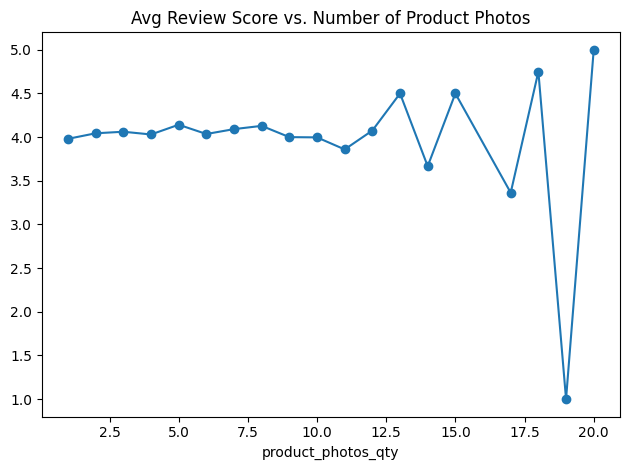

In [52]:
prod_reviews = data['order_items'].merge(products, on='product_id') \
    .merge(data['order_reviews'] if 'order_reviews' in data else data['reviews'], on='order_id')

photo_review = prod_reviews.groupby('product_photos_qty')['review_score'].mean()
photo_review.plot(marker='o', title='Avg Review Score vs. Number of Product Photos')
plt.tight_layout()
plt.show()

In [53]:
cat_price = data['order_items'].merge(products, on='product_id').groupby('product_category_name')['price'].agg(['mean','median','count']).sort_values('mean', ascending=False)
display(cat_price.head(10))

,mean,median,count
product_category_name,,,
pcs,1098.340542,1100.000,203
portateis_casa_forno_e_cafe,624.285658,587.000,76
eletrodomesticos_2,476.124958,225.945,238
agro_industria_e_comercio,342.124858,258.650,212
instrumentos_musicais,281.616000,94.835,680
eletroportateis,280.778468,99.000,679
portateis_cozinha_e_preparadores_de_alimentos,264.568667,34.900,15
telefonia_fixa,225.693182,64.485,264
construcao_ferramentas_seguranca,208.992371,125.575,194


### Sellers — location and revenue spread


seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64


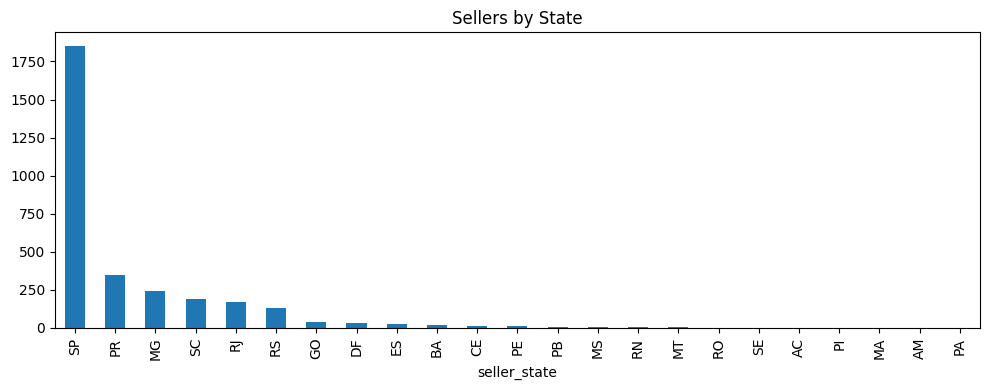

In [54]:
sellers = data['sellers'].copy()

state_counts = sellers['seller_state'].value_counts()
print(state_counts)

state_counts.plot(kind='bar', figsize=(10,4), title='Sellers by State')
plt.tight_layout()
plt.show()

### Customers — location spread, review score by state


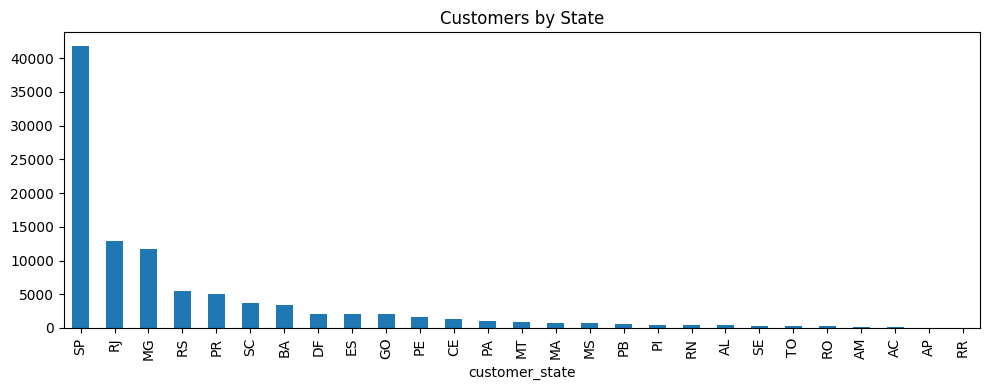

In [55]:
customers = data['customers'].copy()

state_counts = customers['customer_state'].value_counts()
state_counts.plot(kind='bar', figsize=(10,4), title='Customers by State')
plt.tight_layout()
plt.show()

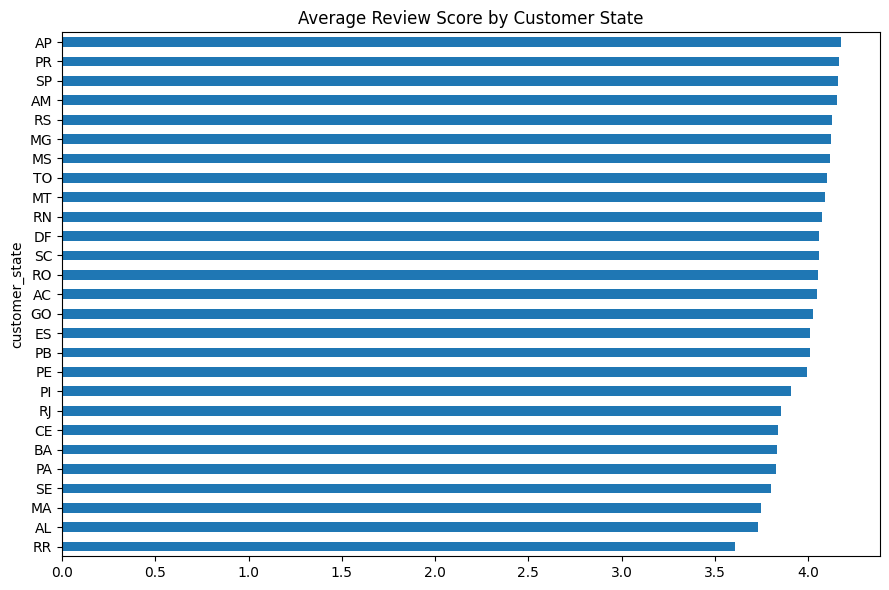

In [56]:
state_review = data['orders'].merge(customers, on='customer_id') \
    .merge(data['order_reviews'] if 'order_reviews' in data else data['reviews'], on='order_id') \
    .groupby('customer_state')['review_score'].mean().sort_values()

state_review.plot(kind='barh', figsize=(9,6), title='Average Review Score by Customer State')
plt.tight_layout()
plt.show()

In [57]:
# Approximate 2018 state population, in millions (general IBGE-based estimates) — used only
# to gauge rough market penetration. Treat as indicative, not authoritative; verify the exact
# figures against an official IBGE source before citing them to the client.
state_population_millions = {
    'SP': 45.5, 'RJ': 17.2, 'MG': 21.0, 'BA': 14.9, 'PR': 11.3, 'RS': 11.3,
    'PE': 9.5, 'CE': 9.1, 'PA': 8.5, 'MA': 7.0, 'SC': 7.0, 'GO': 6.9,
    'ES': 4.0, 'PB': 4.0, 'AM': 4.0, 'RN': 3.5, 'MT': 3.4, 'AL': 3.3,
    'PI': 3.3, 'DF': 3.0, 'MS': 2.8, 'SE': 2.3, 'RO': 1.8, 'TO': 1.6,
    'AC': 0.87, 'AP': 0.85, 'RR': 0.6,
}

customers_by_state = data['customers']['customer_state'].value_counts()
penetration = pd.DataFrame({
    'unique_customers': customers_by_state,
    'population_millions': pd.Series(state_population_millions),
}).dropna()

# Customers per 100,000 people — a simple, comparable penetration measure across states
penetration['customers_per_100k_population'] = (
    penetration['unique_customers'] / (penetration['population_millions'] * 1_000_000) * 100_000
)

display(penetration.sort_values('customers_per_100k_population', ascending=False).head(10))

log("Market saturation check",
    "Leadership wants to know if the low repeat rate is because there's no one left to sell to",
    "Compared unique customers per state against approximate state population (external estimate, not from the raw data)",
    "Even in Sao Paulo -- by far the platform's biggest market -- customers are still a tiny fraction of a percent "
    "of the population, so the low repeat rate isn't explained by running out of people to sell to.")


,unique_customers,population_millions,customers_per_100k_population
SP,41746,45.5,91.749451
RJ,12852,17.2,74.720930
DF,2140,3.0,71.333333
MG,11635,21.0,55.404762
SC,3637,7.0,51.957143
ES,2033,4.0,50.825000
RS,5466,11.3,48.371681
PR,5045,11.3,44.646018
GO,2020,6.9,29.275362
MT,907,3.4,26.676471


**Reading this table:** even São Paulo — Olist's largest market by customer count — only reaches a small fraction of a percent of its total population. No state is anywhere close to running out of potential new customers, so the low repeat-purchase rate isn't a market-saturation story. It points back to the buying experience (delivery delay, review score) rather than the size of the addressable market. (Population figures are approximate, general estimates used for illustration — verify against an official IBGE source before citing this to the client.)


### Reviews — response time, comment behavior, data integrity


Mean response time: 75.5 hours
Median response time: 40.2 hours


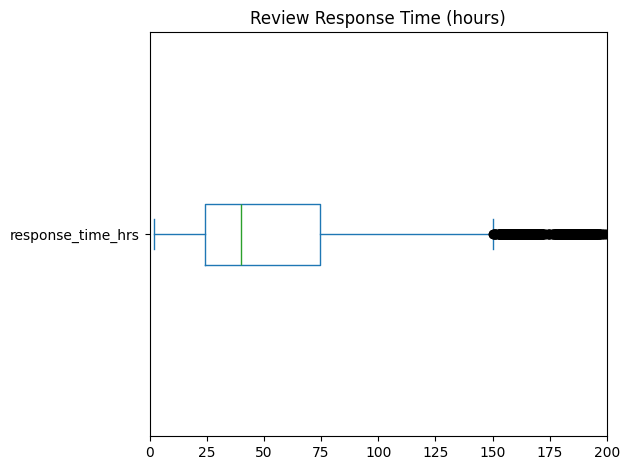

In [58]:
reviews = data['reviews'].copy()

reviews['response_time_hrs'] = (reviews['review_answer_timestamp'] - reviews['review_creation_date']).dt.total_seconds() / 3600

print(f"Mean response time: {reviews['response_time_hrs'].mean():.1f} hours")
print(f"Median response time: {reviews['response_time_hrs'].median():.1f} hours")

reviews['response_time_hrs'].plot(kind='box', vert=False, title='Review Response Time (hours)')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

In [59]:
# Focus specifically on the lowest scores — does Olist respond slower or faster to angry customers?
low_score_response = reviews[reviews['review_score'].isin([1, 2])]['response_time_hrs']
print(f"Score 1-2 reviews — mean response time:   {low_score_response.mean():.1f} hours")
print(f"Score 1-2 reviews — median response time: {low_score_response.median():.1f} hours")
print(f"\nCompared to the overall mean response time: {reviews['response_time_hrs'].mean():.1f} hours")


Score 1-2 reviews — mean response time:   72.9 hours
Score 1-2 reviews — median response time: 38.0 hours

Compared to the overall mean response time: 75.5 hours


Response time to 1-2 star reviews (72.9 hrs mean / 38.0 hrs median) is essentially the same as the overall average (75.5 hrs mean / 40.2 hrs median) -- if anything, marginally faster. Response time is not a meaningful driver here, which keeps the focus cleanly on delivery delay as the actual cause behind Finding 2, rather than diluting it with a non-effect.


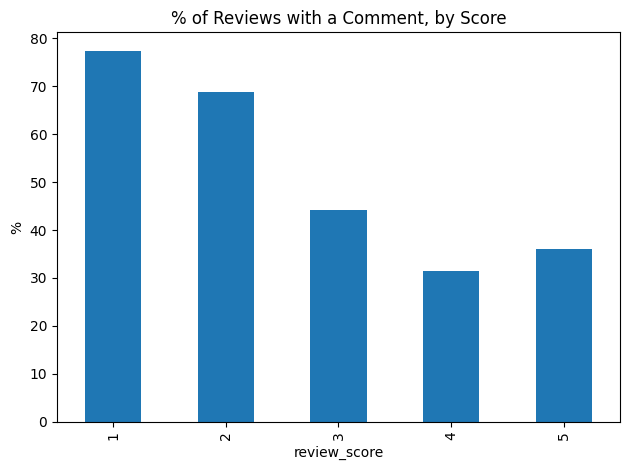

In [60]:
reviews['has_comment'] = reviews['review_comment_message'].notna()
reviews['has_title'] = reviews['review_comment_title'].notna()

comment_by_score = reviews.groupby('review_score')['has_comment'].mean() * 100
comment_by_score.plot(kind='bar', title='% of Reviews with a Comment, by Score')
plt.ylabel('%')
plt.tight_layout()
plt.show()

In [61]:
# Raw counts too, not just percentages — how many reviews of each score come with a comment?
review_counts_by_score = reviews.groupby('review_score')['has_comment'].agg(['sum', 'count'])
review_counts_by_score.columns = ['reviews_with_comment', 'total_reviews']
review_counts_by_score['pct_with_comment'] = (
    review_counts_by_score['reviews_with_comment'] / review_counts_by_score['total_reviews'] * 100
).round(1)
display(review_counts_by_score)


,reviews_with_comment,total_reviews,pct_with_comment
review_score,,,
1,9179,11858,77.4
2,2229,3235,68.9
3,3665,8287,44.2
4,6034,19200,31.4
5,20646,57420,36.0


**How this connects to growth:** low-score reviews (1–2 stars) come with a written comment far more often than 5-star reviews — unhappy customers are much more likely to explain why. If Olist's marketplace shows these comments to future shoppers browsing a listing (a reasonable assumption for a marketplace, but not something confirmed in this dataset), a large volume of visible, detailed 1–2 star comments could scare off new customers before they even buy — turning a delivery-driven review problem into an acquisition problem too, not just a repeat-purchase one. Worth flagging to leadership as a hypothesis to test against real conversion data, not a proven link from this dataset alone.


### Payments — payment methods, installments, join accuracy


,count,pct
payment_type,,
credit_card,76795,73.92
boleto,19784,19.04
voucher,5775,5.56
debit_card,1529,1.47
not_defined,3,0.00


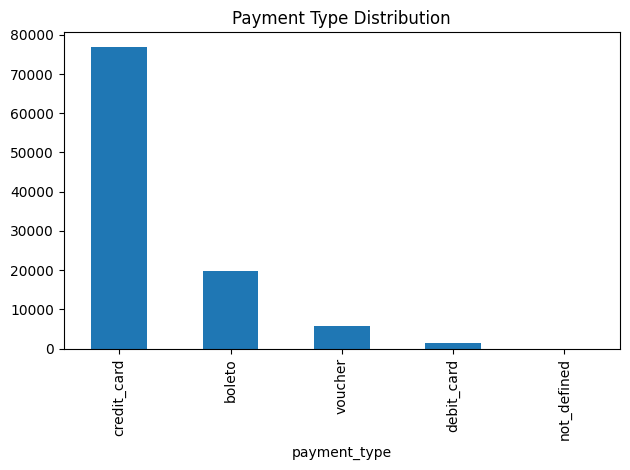

In [62]:
payments = data['payments'].copy()

type_counts = payments['payment_type'].value_counts()
type_pct = (type_counts / len(payments) * 100).round(2)
display(pd.DataFrame({'count': type_counts, 'pct': type_pct}))

type_counts.plot(kind='bar', title='Payment Type Distribution')
plt.tight_layout()
plt.show()

In [63]:
pay_review = payments_agg.merge(analysis[['order_id','review_score']], on='order_id')
score_by_installments = pay_review.groupby(pd.cut(pay_review['max_installments'], bins=[0,1,3,6,12,24]))['review_score'].mean()
print(score_by_installments)

max_installments
(0, 1]      4.176101
(1, 3]      4.135069
(3, 6]      4.115001
(6, 12]     4.065349
(12, 24]    3.865922
Name: review_score, dtype: float64


C:\Users\naren\AppData\Local\Temp\ipykernel_9580\2533746458.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_by_installments = pay_review.groupby(pd.cut(pay_review['max_installments'], bins=[0,1,3,6,12,24]))['review_score'].mean()
